# Regularized CSP and Filter-Bank CSP

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with the regularized version of CSP;
- Get familiar with the Filter-Bank CSP pipeline;

**Solutions file:**
For this assignment, a solutions file will be released after the deadline.

**Note:**
In providing your answers to the questions, please denote which question you are providing an answer to (either in text or code) by commenting it with something like "Exercise 1.1" and "Exercise 3.4". This improves readability of your solutions as well as the quality of the feedback you will get.


## Top-down view onto this notebook
In this notebook you will get to know how to apply the more advanced CSP versions introduced in the lecture.

1. **In exercise 1** - we will deal with the implementation of a regularized CSP (rCSP) class which you can use as drop-in replacement for the plain `mne.decoding.CSP` class. The regularization approach we will use here is the Tikonovh regularization which is a version of an $L_2$ regularization on the CSP weights. We base ourself on the `mne.decoding.CSP` implementation and just overwrite the `.fit(...)` methods. From a technical point of view, this example is also valuable because it shows you how class inheritance can make extendablity easier in programming.
1. **In exercise 2** - we will dive into the filter bank CSP (FBCSP) pipeline. This approach is very popular, as no a priori frequency band selection is required. In this approach, we simply calculate CSP on multiple bands and use machine learning algorithms later to define the most relevant features. The general idea of creating an abundance of features and then having a feature selection step before a final classification, is a wide-spread approach in many other domains. First we will make use of an already existing implementation for FBCSP and compare it to rCSP in terms of decoding performance. You will then be asked to complete a custom implementation of FBCSP to deepen your understanding of the steps involved.

For this assignment, we will make use of one of the most important benchmark data sets for BCI - the [Mother of all BCI Benchmarks](https://github.com/NeuroTechX/moabb) - in short MOABB.


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.utils.validation import check_is_fitted
from sklearn.feature_selection._univariate_selection import _clean_nans
from sklearn.covariance import shrunk_covariance
from sklearn.model_selection import GridSearchCV
from sklearn.base import TransformerMixin, clone

from scipy import signal

import mne
from mne.decoding import CSP

from moabb.paradigms import LeftRightImagery, FilterBankLeftRightImagery
from moabb.datasets import BNCI2014_001, GrosseWentrup2009 

from moabb.evaluations import WithinSessionEvaluation
from moabb.pipelines import FilterBank

import warnings
warnings.filterwarnings('ignore', message='.*warnEpochs', )   # reduce noise from moabb
warnings.filterwarnings('ignore', message='FutureWarning: The current default of copy=False', )   # and from sklearn from within moabb
mne.set_log_level('WARNING')

np.random.seed(42)


---

## Exercise 1: Regularized CSP
### 1.A. Theory
In Lotte et al., 2010 (https://doi.org/10.1109/TBME.2010.2082539, also available here: https://hal.inria.fr/inria-00476820/), the authors present a theoretical framework for regularised versions of the CSP algorithm. In their theory, they introduce two types of regularisations over the CSP algorithm:
- regularisation of the covariance matrix estimates (discussed earlier in the course as *shrinkage regularization*) (section III.A.),
- and regularisation of the CSP objective function (section II.B.).

They call their approach `RCSP` for <u>R</u>egularised <u>CSP</u> and describe its formulas in Table I.
In this notebook, we implemented a simplified version of RCSP and we called it `rCSP`. 
The differences between our simplified version and the one presented in the article are that:
- we assume that $\beta=0$,
- and that $K=I$, with $I$ being an identity matrix.
    
**Questions:**
1. Read the article Lotte et al., 2010 carefully and make sure you understand specifically section III.
1. Read the function `compute_rCSP_components` defined below (i.e., our simplified implementation of `RCSP`) and make sure you understand the link between each code line and the formulas in table I of the article.
1. A list of algorithms is presented in sections IV.A. and IV.B. of the article. Among those algorithms, which ones can be executed using our simplified implementation and which ones can not?



In [3]:
def estimate_regularized_covariance_epochs(X, shrink_param=0.3):
    '''
    This function is similar as the one you saw in assignment 2
    except that, now, X is expected to contains multiple epochs.
    Therefore, X has 3 dimensions: n_epochs * n_channels * n_time_samples
    '''
    n_channels = X.shape[1]
    # we merge the 'epochs' and the 'time_samples' dimensions together
    # because we want to compute the covariance between the channels: 
    X_reshaped = X.transpose(1, 0, 2).reshape(n_channels, -1)
    cov = np.cov(X_reshaped)
    regularized_cov = shrunk_covariance(cov, shrink_param)
    return regularized_cov  # reg cov matrix has shape (n_channels, n_epochs*n_times=n_samples)


In [4]:
def compute_rCSP_components(X, y, gamma, alpha):
    ''' 
    returns: ((lambda1, u1), (lambda2, u2))
        such that lambda<i> is the list of eigenvalues, sorted in decreasing order,
        of matrix M<i>, and u<i> is the matrix containing the eigenvectors sorted the same way.
        
    For more details on the variable names, 
    refer to Lotte et al., 2010 
    '''
    classes = np.unique(y)
    if len(classes)!=2:
        raise ValueError('Expecting a binary classification task')
    # Separate the data elements according to their class:
    X = [X[y==c] for c in classes]
    
    # computing the within-class covariance matrices:
    C = [estimate_regularized_covariance_epochs(Xc, shrink_param=gamma) for Xc in X]
    
    # compute the M matrices:
    n_features = C[0].shape[0]
    M = [np.dot(np.linalg.inv(C[1-i] + alpha*np.eye(n_features)), C[i]) for i in range(2)]
    
    output = []
    for Mc in M:
        # compute the eigenvalues and eigenvectors:
        lbd, u = np.linalg.eig(Mc)
        
        # sort the eigenvectors according to the eigenvalues:
        idx = np.argsort(lbd)[::-1]
        
        output.append((lbd[idx], u[:,idx]))
        
    return output


# Exercise 1, Q3 Answer:
With our simplified CSP which takes β = 0 and K = I identity matrix we can not use any of the methods mentioned in section IV that use those parameters. 
1) Both methods of Composite CSP use β
2) As well as Regularized CSP with Generic Learning
3) and 4. both take β = 0 but the 4th method of invariant CSP is again unusable since it takes for K the covariance matrix of the noise source it wants to make the filters invariant to.  

=> So we can only use 3. Regularized CSP with Diagonal Loading

### 1.B. Inspection of our implementation
Below, we define for you a new class named `rCSP`. 
This class simply wraps our function `compute_rCSP_components` into a scikit-learn object.
By inheritance, this new class is able to use all the methods that were already implemented in `mne.decoding.CSP`.
We are particularly interested in using: `plot_filters` and `plot_patterns`.
As their names indicate, these functions allow to plot the learned spatial filters and their corresponding patterns.
Please look at the [MNE documentation of these functions](https://mne.tools/stable/generated/mne.decoding.CSP.html#mne.decoding.CSP.plot_filters) to learn how to use them.

In one of the cells below, we load some data from [a motor imagery dataset](http://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014001.html#moabb.datasets.BNCI2014001) 
(keeping only the right and left hand classes).
Then, we train the regular CSP implementation from MNE to generate filters that separate these classes.
Finally, we plot these spatial filters and patterns (only the first 6 filters).

*Note:* The data is automatically downloaded and loaded using the [MOABB library](http://moabb.neurotechx.com/docs/index.html).

**Questions:**
1. Inspect the `rCSP` class. What arguments does it expect? 
1. Execute the cells already provided.
1. Train our rCSP implementation on the data already loaded **without any regularisation** (i.e., with regularisation parameters set to 0).
1. Plot the spatial filters and patterns that have been learned by rCSP and compare them to the ones that were learned by CSP. Are they similar? Should they be similar?
1. Could you have compared the filters of the two CSP versions using the numpy function `np.allclose` (read the function's documentation if necessary)? Explain why.
1. Play with different regularization parameters, for each pair of parameters: 
    - Train rCSP with those parameters;
    - describe the filters and patterns you expect to see;
    - plot the patterns and filters;
    - comment on your observations.
    

In [5]:
class rCSP(CSP):
    def __init__(self, n_components=4, gamma=0, alpha=0):
        # new parameters
        self.gamma = gamma
        self.alpha = alpha
        super().__init__(
            # altered parameters:
            n_components=n_components, component_order='alternate',
            # default parameters:
            reg=None, log=None, cov_est='concat', 
            transform_into='average_power', norm_trace=False, 
            cov_method_params=None, rank=None,
        )
        self.filters_ = None
        self.patterns_ = None
        
    def fit(self, X, y):
        self._check_Xy(X, y)
        self._classes = np.unique(y)
        
        N_channels = X.shape[1]
        
        # Compute the filters:
        (lambda1, u1), (lambda2, u2) = compute_rCSP_components(X, y, gamma=self.gamma, alpha=self.alpha)
        
        # Below, we merge the lists of eigenvalues and eigenvectors in a "zipper" pattern.
        # This means that lbd will contain first the largest eigenval of lambda1,
        # then the largest eigenvalue of lambda2, then the second largest eigenvalue of lambda1,
        # then the second largest value of lambda2, etc... 
        # The eigenvectors are merged in the same order as the eigenvalues.
        # This order is the same as in mne.decoding.CSP(component_order='alternate').
        n_eig = len(lambda1)
        lbd = np.stack([lambda1, lambda2]).T.flatten()
        u = np.stack([u1.T,u2.T]).transpose(1,0,2).reshape(2*n_eig,-1) 
        
        # Save the filters and patterns:
        self.filters_ = u[:N_channels,:]
        self.patterns_ = np.linalg.pinv(u.T)
        return self
    

c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\moabb\paradigms\base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


Filters | mne.decoding.CSP:


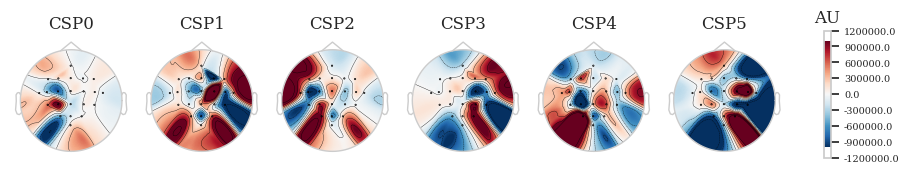

Patterns | mne.decoding.CSP:


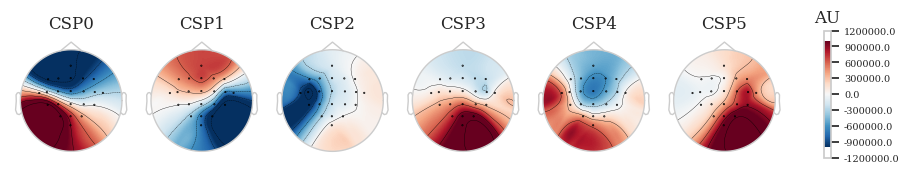

In [6]:
# The dataset we will use:
dataset = BNCI2014_001() # http://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014001.html#moabb.datasets.BNCI2014001
subject = 1
session = '1test'   # 'session_E' in older moabb versions

# Pre-processing parameters:
fmin = 8
fmax = 12
resample = 24

# CSP parameters:
n_components = 6

# Visualisation parameters:
vmax_filter = 1e6
vmin_filter = -vmax_filter
vmax_pattern = 1e6
vmin_pattern = -vmax_pattern


# Load some data: 
paradigm = LeftRightImagery(fmin=fmin, fmax=fmax, resample=resample)
epochs, y, metadata = paradigm.get_data(dataset, subjects=[subject], return_epochs=True)

# We only keep the data from one session:
epochs, y = epochs[metadata.session==session], y[metadata.session==session]

# We extract a numpy array and multiply by 1e6 to go from Volts to micro Volts
X = epochs.get_data() * 1e6

# Train MNE's CSP implementation:
csp = CSP(n_components=n_components, component_order='alternate').fit(X, y)

# Plot the filters and patterns:
print('Filters | mne.decoding.CSP:')
csp.plot_filters(info=epochs.info, vlim=(vmin_filter,vmax_filter))
print('Patterns | mne.decoding.CSP:')
csp.plot_patterns(info=epochs.info, vlim=(vmin_pattern,vmax_pattern))
plt.show()


Filters | class rCSP:


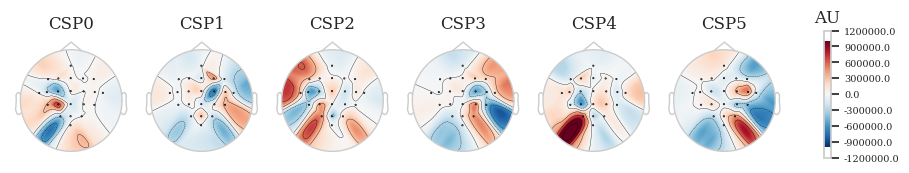

Patterns | class rCSP:


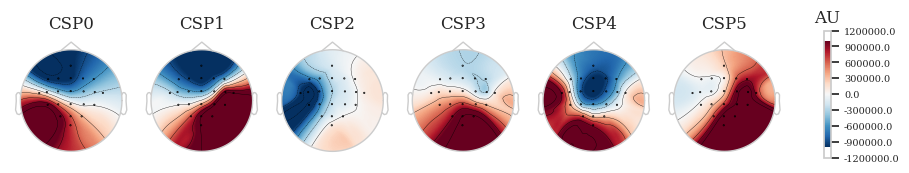

In [7]:
# Answer here:
# 1) The arguments the class expects is n_components, gamma and alpha

# Train new rCSP implementation:
rcsp = rCSP(n_components=n_components).fit(X, y) # gamma and alpha default values are 0

print('Filters | class rCSP:')
rcsp.plot_filters(info=epochs.info, vlim=(vmin_filter,vmax_filter))
print('Patterns | class rCSP:')
rcsp.plot_patterns(info=epochs.info, vlim=(vmin_pattern,vmax_pattern))
plt.show()

# 4
The patterns and filters of CSP and rCSP are similar as they should since at the moment we are not using any regularization.The parameters α and γ of rCSO are equal to 0, therefore, theoretically the rCSP method should be identical to the CSP method. The shape is the same aside from some numerical differences due to implementation details (darker values of filters in normal CSP).

# 5
No, np.allclose cannot be used to compare CSP and rCSP filters.
Eigenvectors are not unique due to sign ambiguity, and even small numerical differences can change the ordering of eigenvectors. Therefore the filters and patterns can look visually similar but only on the rare case will be numerically equal.

Filters rCSP | alpha=0.0, gamma = 0.0


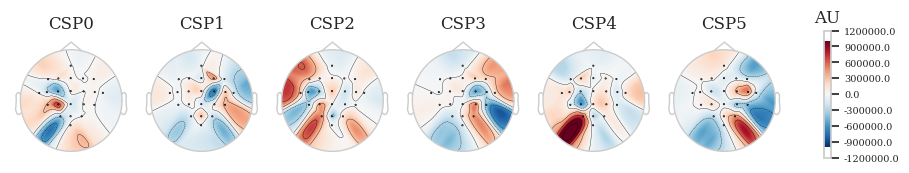

Patterns rCSP | alpha=0.0, gamma = 0.0


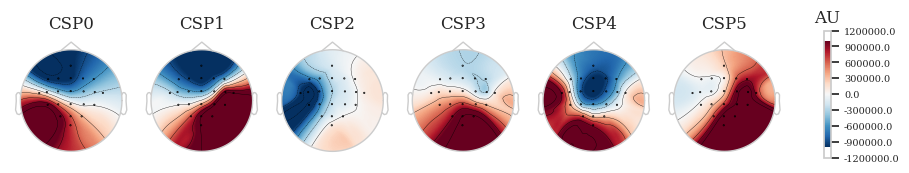


Filters rCSP | alpha=0.1, gamma = 0.0


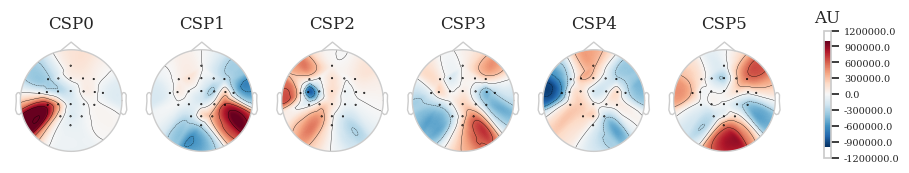

Patterns rCSP | alpha=0.1, gamma = 0.0


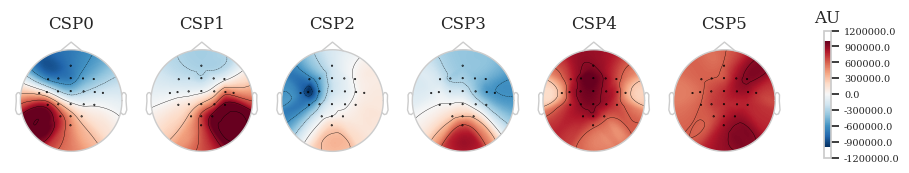


Filters rCSP | alpha=0.5, gamma = 0.0


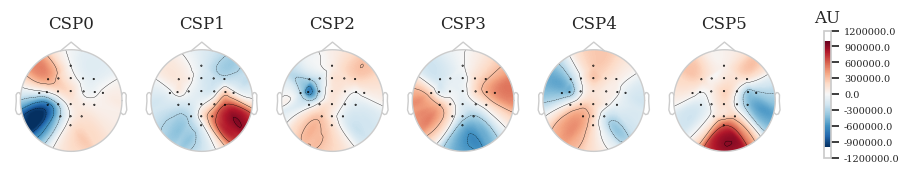

Patterns rCSP | alpha=0.5, gamma = 0.0


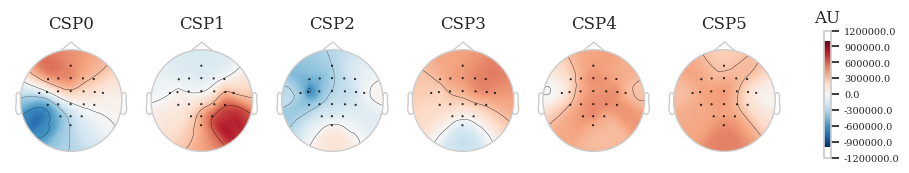


Filters rCSP | alpha=0.0, gamma = 0.1


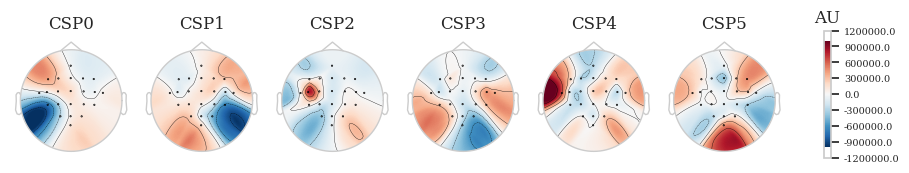

Patterns rCSP | alpha=0.0, gamma = 0.1


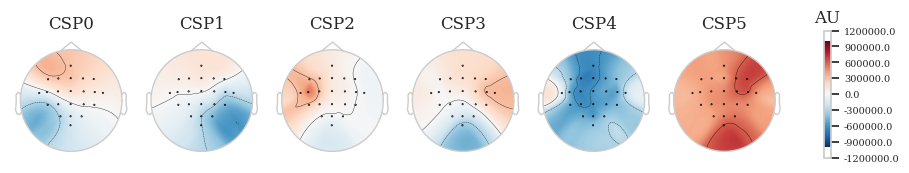


Filters rCSP | alpha=0.1, gamma = 0.1


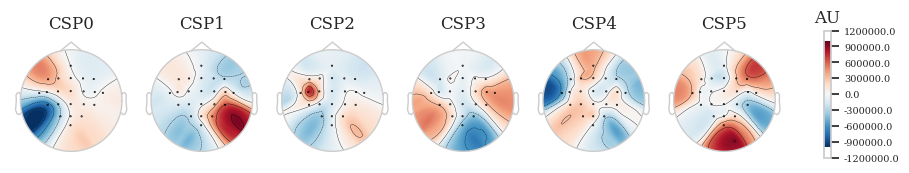

Patterns rCSP | alpha=0.1, gamma = 0.1


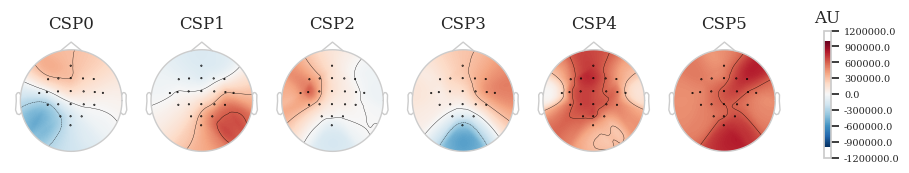


Filters rCSP | alpha=0.5, gamma = 0.1


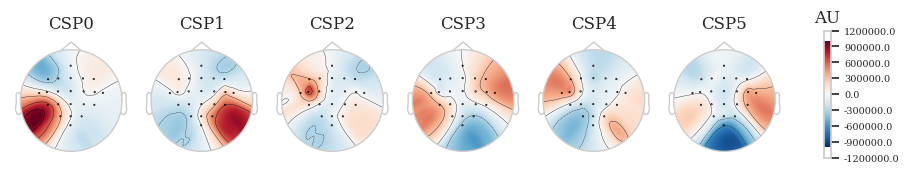

Patterns rCSP | alpha=0.5, gamma = 0.1


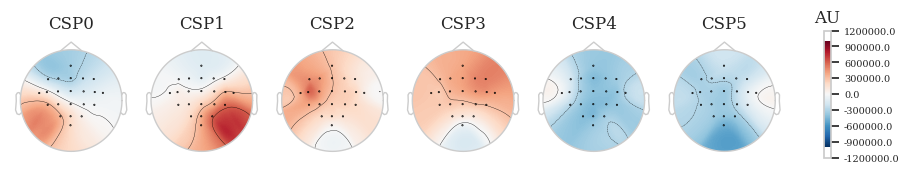


Filters rCSP | alpha=0.0, gamma = 0.5


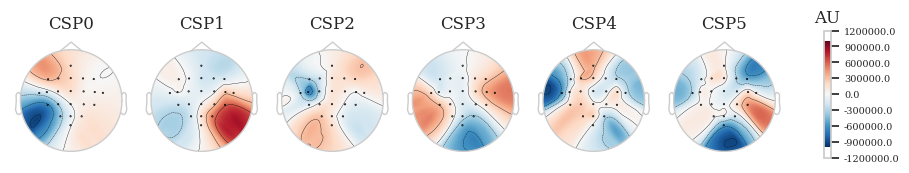

Patterns rCSP | alpha=0.0, gamma = 0.5


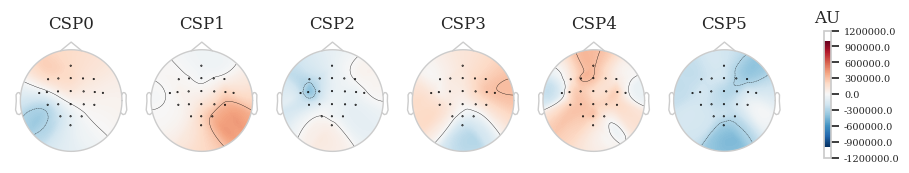


Filters rCSP | alpha=0.1, gamma = 0.5


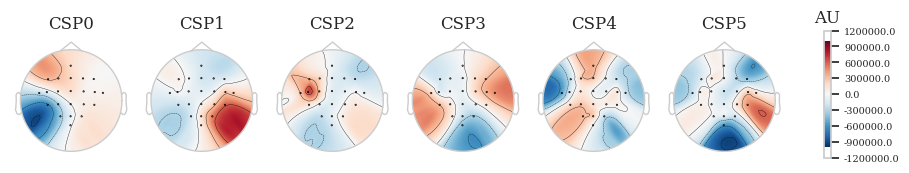

Patterns rCSP | alpha=0.1, gamma = 0.5


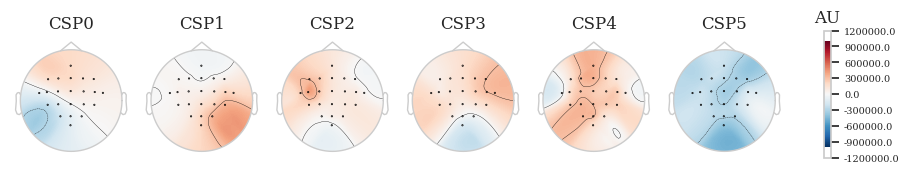


Filters rCSP | alpha=0.5, gamma = 0.5


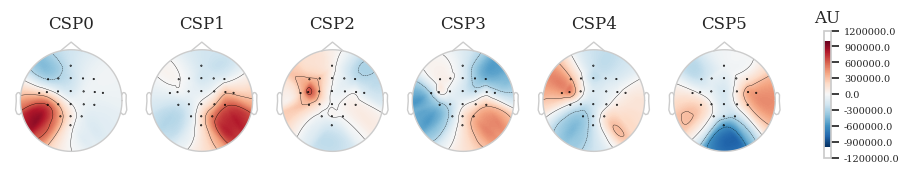

Patterns rCSP | alpha=0.5, gamma = 0.5


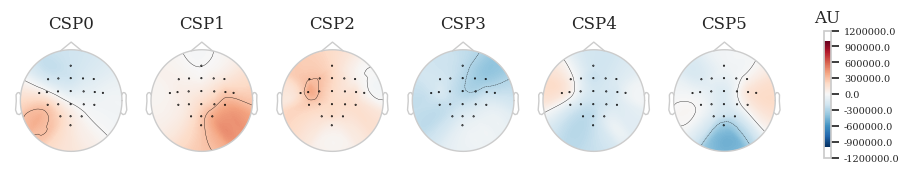

In [8]:
gammas = [0.0, 0.1, 0.5]
alphas = [0.0, 0.1, 0.5]

for gamma in gammas:
    for alpha in alphas:
        # Train new rCSP implementation:
        rcsp = rCSP(n_components=n_components, gamma=gamma, alpha=alpha).fit(X, y) # gamma and alpha default values are 0

        print(f'Filters rCSP | alpha={alpha}, gamma = {gamma}')
        rcsp.plot_filters(info=epochs.info, vlim=(vmin_filter,vmax_filter))
        print(f'Patterns rCSP | alpha={alpha}, gamma = {gamma}')
        rcsp.plot_patterns(info=epochs.info, vlim=(vmin_pattern,vmax_pattern))
        plt.show()
        print()

# Expectations and Observations
The $\alpha$ parameter acts on the penalty on the objetive function which is just a an $L_2$ since K matrix is equal to 1. So it punishes the large values of the weights as seen in the filters. What we expect to see is a decrease in amplitude and more of a smearing. The higher the alpha the higher the $L_2$ pentalty term on the objective function of the weights. As we can see from the change of $\alpha = 0 \rightarrow 0.1$ there is less of a localization on a single channel and more of a combination of channels.

The $\gamma$ parameter has an affect (shrinkage) on the covariance matrix and an indirect effect on the weights. The patterns should become smoother and the peaks disappear which is indeed what we observe even for a small value of $\gamma = 0.1$. It is a bit difficult to explain the change here on the patterns based on this parameter from the equations but is is quite visible.

### 1.C. Impact of the regularisation
In this section, we will explore the impact of the different regularisation parameters on the performance of RCSP in difficult cases, such as when little training data is available.

To evaluate the pipeline in these conditions, we will again use the MOABB library. 
MOABB allows you to benchmark your classification algorithms on BCI data in different scenarios.
The senario we will use is the [within-session evaluation](http://moabb.neurotechx.com/docs/generated/moabb.evaluations.WithinSessionEvaluation.html#moabb.evaluations.WithinSessionEvaluation)
in which the scores are computed by k-folds cross-validation over the examples from a single session,
and that for every subject and every session.
Below, we also wrote for you functions that can plot the results of MOABB evaluations (i.e. [pandas dataframes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)).

We defined a list of pipelines that have different regularisation parameters,
and we trained them using multiple different training set sizes (i.e., 4, 12, 32, 96, and 240 training examples).
We then plotted their results using one of our function.
Our goal will be to analyse this plot. 

**Questions:**
1. Observe the plot below. Which parameters obtain the best score when few training trials are available? And which one has the best score when more training trials are used? Explain why.
1. When very few training examples are used (i.e., 4 training examples), we observe that all the pipelines seem to obtain the same score. Can you explain why?
1. We want to find a good value for $\gamma$ when only 20 training trials are available. What would be the problem if we tried to use a function such as `GridSearchCV` on 20 training samples?
1. Try a few regularisation parameters, compare the average scores obtained and write which parameter is the best.
1. Can you think of other difficult cases where the regularisation of CSP could be useful? 
1. (Optional) Find new data that represents another difficult data scenario or simulate it. Then, test if the regularisation is able to improve the classification performance in this case. 
<!-- 1. How much training data is needed on average to reach 70% accuracy for the different algorithms -->

In [9]:
sns.set_context('notebook')

def plot_results(results, title=None, **kwargs):
    '''
    Plots the average accuracy of each pipeline as points.
    The vertical bars correspond to the standard errors between the different evaluations. 
    The light points in the back are the individual evaluations 
    (i.e., on different subjects, sessions, and cross-validation folds).
    
    If different training set sizes were evaluated,
    one subplot per training set size is created.
    '''
    col = 'data_size' if 'data_size' in results and len(results.data_size.unique())>1 else None
    g = sns.catplot(
        kind='strip',
        data=results,
        y="score",
        x="pipeline",
        jitter=True,
        alpha=0.3,
        zorder=1,
        palette="Set1",
        hue="pipeline",
        col=col,
        **kwargs,
    )
    g.map_dataframe(
        sns.pointplot,
        y="score", 
        x="pipeline", 
#         zorder=1, 
        palette="Set1",
    )
    g.set(
        ylabel="accuracy",
        # ylim=(0.5, 1),
    )
    g.fig.suptitle(title)
    for ax in g.axes.ravel():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    return g

def plot_results_bars(results, title=None, **kwargs):
    '''
    Plots the average accuracy of each pipeline on each subject as vertical bars.
    The narrow vertical black bars correspond to the standard errors between the different evaluations. 
     
    If different training set sizes were evaluated,
    one subplot per training set size is created.
    '''
    col = 'data_size' if 'data_size' in results and len(results.data_size.unique())>1 else None
    g = sns.catplot(
        kind='bar',
        data=results,
        y="score",
        x="subject",
        hue='pipeline',
        zorder=1,
        palette="Set1",
        col=col,
        **kwargs,
    )
    g.set(
        ylabel="accuracy",
        # ylim=(0.5, 1),
    )
    g.fig.suptitle(title)
    return g
    
    
def plot_results_multi_sizes(results, title=None, **kwargs):
    '''
    Plots the average accuracy of each pipeline for the different training set sizes tested as line plots.
    The colored bands correspond to the standard errors between the different evaluations. 
    '''
    markers = ['o']*len(results.pipeline.unique())
    ticks = results.data_size.unique()
    ticks = np.sort(ticks[~np.isnan(ticks)].astype(int)).tolist()
    g = sns.relplot(
        kind='line',
        data=results, 
        y="score",
        x="data_size",
        hue="pipeline",
        style='pipeline',
        markers=markers,
        dashes=False,
        palette="Set1",
        **kwargs,
    )
    g.set(
        xlabel="number of training samples",
        ylabel="accuracy",
        xscale='log',
        xticks=ticks,
        xticklabels=ticks,
        # ylim=(0.5, 1),
    )
    g.fig.suptitle(title)
    return g

In [10]:
print('alpha=\u03B1, gamma=\u03B3')

alpha=α, gamma=γ


In [11]:
# To have a better idea of the impact of regularization, we use another data set:
dataset = GrosseWentrup2009() # http://moabb.neurotechx.com/docs/generated/moabb.datasets.MunichMI.html#moabb.datasets.MunichMI < was referred to as MunichMI in older moabb versions

# In this dataset, one subject is approximately 700MB.
# Therefore, we will only evaluate rCSP on one subject.
# If your laptop has a decent ram and you have time to download more data, 
# you can comment the two lines below to use all the subjects.
subjects = [1]
dataset.subject_list = subjects 

In [12]:
# Define a random state for reproducible results:
np.random.seed(3)

# Define the regularisation parameters to try:
alphas = [.1, .5]
gammas = [.1, .3]

# Define the number of CSP components:
n_components = 4

    
# Define the pipelines:
pipelines = dict()
pipelines['CSP no reg.'] = make_pipeline(
    rCSP(n_components=n_components, alpha=0.0, gamma=0.0), 
    LDA(),
)
for alpha, gamma in zip(alphas+[0]*len(gammas), [0]*len(alphas)+gammas):
    name = f'rCSP \u03B1={alpha},\u03B3={gamma}'
    pipelines[name] = make_pipeline(
        rCSP(n_components=n_components, alpha=alpha, gamma=gamma),
        LDA(),
    )

# Define the evaluation parameters:
overwrite = True # overwrite the results that were already computed
data_size = dict(
    policy='per_class',
    value=[2, 6, 16, 48, 120] # training set sizes to try
)
n_perms = [20, 20, 10, 5, 5] # number of permutations to try (for every dataset size)

# Evaluate the pipelines using MOABB:
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=[dataset], overwrite=overwrite, 
    data_size=data_size, n_perms=n_perms,
)
results = evaluation.process(pipelines)


GrosseWentrup2009-WithinSession: 100%|██████████| 1/1 [02:32<00:00, 152.65s/it]


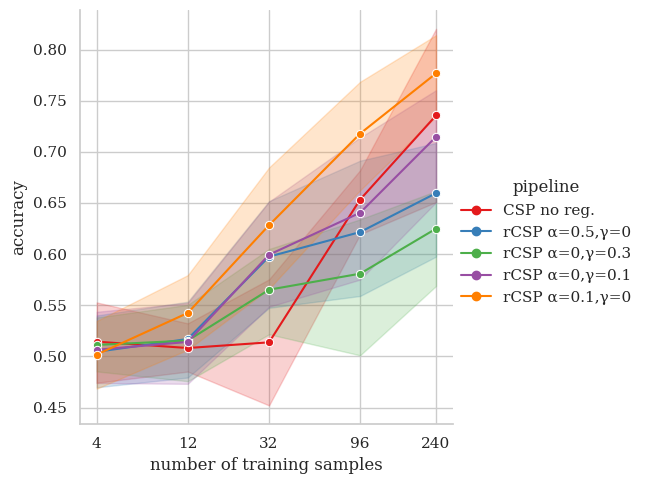

In [13]:
# plot_results(results)
plot_results_multi_sizes(results)
plt.show()

## Exercise 1C 
## Q1
For the least amount of training trials, 4, all parameters obtain a similar score around chance level. The standard CSP with no regularization is slightly ahead while the orange rCSP with $\alpha = 0.1$ is last. For all other steps the orange rCSP is first with increasing margin until the last run which had the most number of training samples, 240 which still has a considerable lead of the second method of no reg CSP.

With few training samlpes the covariance matrices are noisy and we can see for 12 and 32 training samples regularized parameter methods have a better performance. Once the training samples reach a certain threshold the no reg CSP reaches a good accuracy and ever surpasses some regularized algorithms. With even more they should converge together even with the orange pipeline. It also seems that a small $\alpha$ regularization works better than a large one, similarly with the $\gamma$. Regularizing too much leads to punishing the weights and losing signal from the data.

## Q2 

There is not enough data for the parameters and covariance to be estimated reliably so the LDA classifier especially after averaging over the permutations converges to chance levels for all parameter algorithms. There is 2 examples per class and with components of CSP being 4 the decision boundary of the LDA is unstable. Therefore, there is no meaningful difference in performance considering the variance of each result.

## Q3
With only 20 trials, performing GridSearchCV would split the data into extremely small training and validation folds, producing unbalanced covariance estimates and noisy validation accuracy. As a result, the γ chosen by GridSearchCV would be driven by random fluctuations rather than true performance, leading to overfitting and an unreliable regularisation parameter.

## Q4
The best regularization parameters are γ = 0 and α = 0.1 as per the explanation of Q1

## Q5
* Large number of channels/ High dimensional data
* Low signal-to-noise ration, like weak oscillatory contrast or high noise in signals
* Label noise
* Small number of data (this example)


---

##  Exercise 2: Filter-Bank CSP
### 2.A. Discover FBCSP
We will now focus on a popular pipeline that uses CSP. This pipeline is called Filter-Bank CSP (FBCSP) and won several BCI competitions (Tangermann et al., 2012, https://doi.org/10.3389/fnins.2012.00055). 
In its classical implementation, FBCSP follows the steps:
1. band-pass filtering of the raw signal on multiple frequency bands
1. epoching the signal
1. applying the (R)CSP algorithm one time per frequency band
1. concatenating the CSP features from all the frequency bands into one feature vector
1. apply a feature selection algorithm
1. classify the features using, e.g., the LDA algorithm

For more details on FBCSP, you can read the original article Ang et al., 2008 (https://doi.org/10.1109/IJCNN.2008.4634130).

The `moabb.pipelines.FilterBank` class in combination with `moabb.paradigms.FilterBankLeftRightImagery` does the **steps 1-4** for you. 
The `SelectKBestCSP` class we defined below implements the **step 5** (feature selection).
Take a look at the implementation of the FBCSP pipeline we have provided below to have an example of how to use these classes.

You will find a code cell below which trains both, a regular CSP pipeline and the FBCSP one.

We observe a significant difference between the two pipelines for subject 5.
The goal is to investigate the selected bands for this subject.

**Questions:**
1. In which plot can you observe that FBCSP performs better than CSP on average? In which plot can you observe the difference for subject 5?
1. In theory, what advantages do you see in using FBCSP over regular CSP?
1. Investigate the features selected for subject 5. Can you explain why CSP is performing so much worse for this subject? *Hint:* you might want to use the function `print_fbcsp_features` which we have defined for you below.
1. What would you need to change in the decoding pipeline in order to get better results for subject 5? Consider what you learned in the previous question. Please describe and run another evaluation for the subjects.
1. Which filter bands are the most informative ones across subjects?


In [14]:
class SelectKBestCSP(SelectKBest):
    '''
    must be used with only two classes and either CSP(n_components=n_csp_components, component_order='alternate')
    or simply rCSP(n_components=n_csp_components)
    '''

    def __init__(self, score_func=None, *, n_csp_components=None, k=10):
        if n_csp_components % 2 != 0:
            raise ValueError()
        super().__init__(score_func=score_func, k=k)
        self.n_csp_components = n_csp_components

    def _get_support_mask(self):
        check_is_fitted(self)

        if self.k == "all":
            return np.ones(self.scores_.shape, dtype=bool)
        elif self.k == 0:
            return np.zeros(self.scores_.shape, dtype=bool)
        else:
            scores = _clean_nans(self.scores_)
            mask = np.zeros(scores.shape, dtype=bool)
            for i in range(self.k):
                if np.all(mask):
                    break
                imax = np.arange(len(mask))[~mask][np.argmax(scores[~mask])]
                other = 1 if imax % 2 == 0 else -1
                mask[imax] = 1
                # select the matching component:
                assert mask[imax + other] == False
                mask[imax + other] = 1
            return mask
        

In [15]:
# Here we go back to the BNCI data set as it is smaller and thus can be processed faster
dataset = BNCI2014_001()

# Define the regularisation parameters:
alpha = 0.0
gamma = 0.0

# Define the number of components:
n_components = 4
n_selected_features = 4

# define the pipelines:
csp_pipelines = dict()
csp_pipelines['rCSP'] = make_pipeline(
    rCSP(n_components=n_components, alpha=alpha, gamma=gamma), 
    LDA(),
)
pipelines_fb = dict()
pipelines_fb['FBCSP'] = make_pipeline(
    FilterBank(rCSP(n_components=n_components, alpha=alpha, gamma=gamma)),
    SelectKBestCSP(mutual_info_classif, n_csp_components=n_components, k=n_selected_features), # MIBIF4
    LDA(),
)

# Define the frequency filtering parameters:
filters = [[8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 35]] # i.e. bank of 6 filters, by 4 Hz increment
fmin = 8
fmax = 12
resample = 80

# Define the evaluation parameters:
overwrite = True # overwrite the results that were already computed
data_size = None # use all the training data available to perform a 5 folds cross-validation
n_perms = None

# Evaluate the pipelines:
paradigm_csp = LeftRightImagery(fmin=fmin, fmax=fmax, resample=resample)
evaluation = WithinSessionEvaluation(
    paradigm=paradigm_csp, datasets=[dataset], overwrite=overwrite, 
    data_size=data_size, n_perms=n_perms,
)
results = evaluation.process(csp_pipelines)
paradigm_fb = FilterBankLeftRightImagery(filters=filters, resample=resample,)
evaluation_fb = WithinSessionEvaluation(
    paradigm=paradigm_fb, datasets=[dataset], overwrite=overwrite,
    data_size=data_size, n_perms=n_perms,
)
results_fb = evaluation_fb.process(pipelines_fb)

# Merge the FBCSP results and the CSP results: 
results_joined = pd.concat([results, results_fb]).reset_index()

BNCI2014-001-WithinSession:   0%|          | 0/9 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-001-WithinSession:  11%|█         | 1/9 [00:04<00:36,  4.57s/it]Downloading data from 'http://bnci-horizon-2020.eu/database/data-sets/001-2014/A02T.mat' to file 'C:\Users\ptrso\mne_data\MNE-bnci-data\database\data-sets\001-2014\A02T.mat'.
c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\urllib3\connectionpool.py:1063: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\urllib3\connectionpool.py:1063: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|#############################################| 43.1M/43.1M [00:00<?, ?B/s]
SHA256 hash o

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-001-WithinSession:  22%|██▏       | 2/9 [00:17<01:07,  9.71s/it]Downloading data from 'http://bnci-horizon-2020.eu/database/data-sets/001-2014/A03T.mat' to file 'C:\Users\ptrso\mne_data\MNE-bnci-data\database\data-sets\001-2014\A03T.mat'.
c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\urllib3\connectionpool.py:1063: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
c:\Users\ptrso\.conda\envs\bci-course\lib\site-packages\urllib3\connectionpool.py:1063: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|#############################################| 44.1M/44.1M [00:00<?, ?B/s]
SHA256 hash o

...

BNCI2014-001-WithinSession:  78%|███████▊  | 7/9 [03:23<00:59, 29.84s/it]

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-001-WithinSession:  89%|████████▉ | 8/9 [03:54<00:29, 29.95s/it]

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-001-WithinSession: 100%|██████████| 9/9 [04:22<00:00, 29.11s/it]


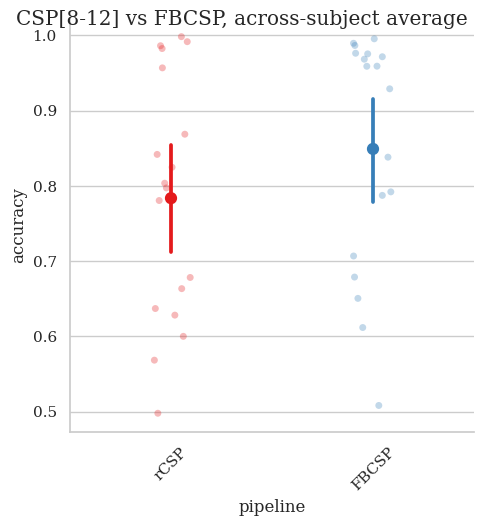

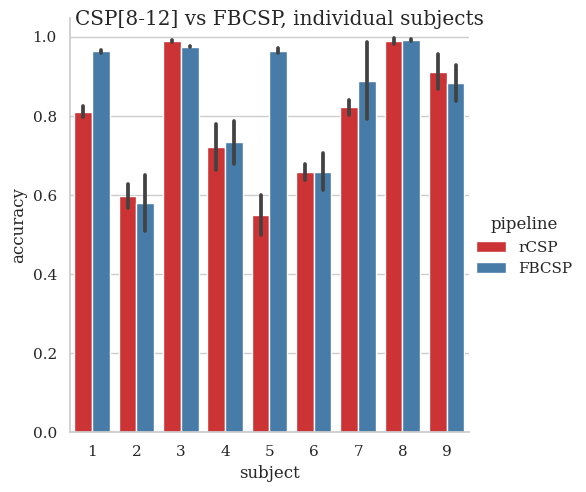

In [16]:
plot_results(results_joined, title=f'CSP[{fmin}-{fmax}] vs FBCSP, across-subject average')
plot_results_bars(results_joined, title=f'CSP[{fmin}-{fmax}] vs FBCSP, individual subjects')
# plot_results_multi_sizes(results)
plt.show()

In [17]:
def print_fbcsp_features(fbcsp, all_features=True, selected_features=True):
    ''' 
    This function can be used to print out the concatenation 
    of the features from all the CSP instances
    and the specific features that were selected by MIBIF4. 
    '''
    filters_np = np.array(filters)  # the frequency ranges
    scores_features = fbcsp['selectkbestcsp'].scores_
    if all_features:
        idx = np.argsort(scores_features)[::-1]
        print('Features from all the CSP algorithms sorted by decreasing order of importance:')
        for i, s, f in list(zip(idx, scores_features[idx], filters_np[idx//n_components])):
            print(f'- feature{i:3d}: score={s:.3f}, band={f}')

    if selected_features:
        idx_selected = fbcsp['selectkbestcsp'].get_support(indices=True) 
        print('\nFeatures selected by the MIBIF4 algorithm:')
        for i, s, f in list(zip(idx_selected, scores_features[idx_selected], filters_np[idx_selected//n_components])):
            print(f'- feature {i:3d}: score={s:.3f}, band={f}')

In [21]:

subject = 5

paradigm_fb = FilterBankLeftRightImagery(filters=filters,resample=resample)

X, y, metadata = paradigm_fb.get_data(
    dataset,
    subjects=[subject],
    return_epochs=False
)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

# FBCSP pipeline
fbcsp = make_pipeline(
    FilterBank(
        rCSP(n_components=n_components, alpha=alpha, gamma=gamma)
    ),
    SelectKBestCSP(
        mutual_info_classif,
        n_csp_components=n_components,
        k=n_selected_features
    ),
    LDA()
)

fbcsp.fit(X, y)
print("Pipeline fitted on subject 5.")

print_fbcsp_features(
    fbcsp,
    all_features=True,
    selected_features=True
)


Data shape: (288, 22, 320, 6)
Labels shape: (288,)
Pipeline fitted on subject 5.
Features from all the CSP algorithms sorted by decreasing order of importance:
- feature 20: score=0.402, band=[28 35]
- feature 21: score=0.256, band=[28 35]
- feature 17: score=0.140, band=[24 28]
- feature  7: score=0.090, band=[12 16]
- feature 22: score=0.085, band=[28 35]
- feature 13: score=0.077, band=[20 24]
- feature  8: score=0.073, band=[16 20]
- feature 12: score=0.065, band=[20 24]
- feature 11: score=0.064, band=[16 20]
- feature  5: score=0.063, band=[12 16]
- feature 23: score=0.060, band=[28 35]
- feature  0: score=0.055, band=[ 8 12]
- feature 15: score=0.043, band=[20 24]
- feature  1: score=0.041, band=[ 8 12]
- feature  2: score=0.038, band=[ 8 12]
- feature 16: score=0.034, band=[24 28]
- feature  3: score=0.032, band=[ 8 12]
- feature 10: score=0.029, band=[16 20]
- feature 19: score=0.025, band=[24 28]
- feature  9: score=0.011, band=[16 20]
- feature 18: score=0.009, band=[24 28]


# Answer here: 
## 2.1) 
The first plot very clearly shows the difference in accuracy between the averages of CSP and FBCSP. FBCSP has an average accuracy of about 0.85 and normal CSP about 0.79. In the second plot, you can see the difference between individual subjects. Here we can observe that FBCSP performs much better on subject 5 compared to rCSP.
## 2.2)
FBCSP has better accuracy than regular CSP, which is mainly due to FBCSP preserving class-specific information by using spatial filters, and applying CSP on every frequency band. It can also create a model with more features and better regularization without overfitting because of the filters.
## 2.3)
CSP performs much worse for subject 5 because it only uses the 8–12 Hz band, where this subject activity is not discriminative at all. The informative features for this subject are mainly in 24–35 Hz, which CSP never sees. FBCSP evaluates multiple frequency bands and correctly selects the higher-frequency components, so it performs much better.

### 2.B. (Optional) Your own FBCSP implementation
Finally, you will implement your own FBCSP based of the rCSP class defined above. This will help you internalize the steps of FBCSP mentioned above!

Hint: You can have a look at [the moabb FilterBank](http://moabb.neurotechx.com/docs/generated/moabb.pipelines.utils.FilterBank.html) implementation for a high level idea.

**Questions**:
1. Complete the myFBCSP class below.
1. Compare the result of the feature generation selected on your FBCSP implementation. 
1. Discuss where differences between your version and the moabb version could originate from.

In [ ]:
# Assume we will be working of this data - subject 3 is chosen as an example
paradigm_broadband = LeftRightImagery(fmin=1, fmax=35, resample=80)
X, y, _ = paradigm_broadband.get_data(dataset, subjects=[3], return_epochs=False)
X.shape             # What are the dimensions we see ?

(288, 22, 320)

In [ ]:
class myFBCSP(CSP):
    def __init__(self, n_components=4, gamma=0, alpha=0, fs=80, filters=None):
        # new parameters
        self.gamma = gamma
        self.alpha = alpha
        self.fs = fs
        self.filters = ([8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32]) if filters == None else filters
        
        
    def fit(self, X, y):
        """ Fit a filterbank CSP
        
        Parameters
        ----------
        X : np.ndarray
            data in dimensions (n_epochs, n_channels, n_times) - note that moabb gets the data via specifying
            a paradigm. See the previous cell. You could also use this to create data within frequency bands
            already, which would then require a different fit function.
            
            Here we want to be as close to the mne library as possible on purpose! Hence the dummies down below.
        y : np.ndarray
            the labels in dimensions (n_epochs,)
        """
        self._check_Xy(X, y)
        self._classes = np.unique(y)

        self.CSP_models = []        # here we will store the individual CSP models
        for freq_range in self.filters:
            pass
            # your implementation here
        
      
        return self
    
        
    def transform(self, X):
        Xt = []
        
        # Here you will need a similar loop as within the fit method
        # your implementation here
        
        Xt = np.stack(Xt, axis=2)       # just cast to numpy and stack along a new axis=2
        
        # The output should be of dimension (n_epochs, n_components x n_frequency_bands)
        return np.vstack(Xt.T).T


---

## (Optional) Exercise 3: To go further - regularised version of SPoC
1. Read Meinel et al., 2019 (https://doi.org/10.1007/s12021-018-9396-7)
1. Implement one of the regularised version of SPoC (see Table 1 of the article).
1. Play with it 😀

In [ ]:
# Answer here:


---

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

Exercise 1 - Petros  
Exercise 2 - Laurens   
Exercise 2.3 - Petros